# Transfer Function Inversion (Staged Workflow)

Stages:
1. Configure inputs and load fit data
2. Estimate boundary-delay term with diagnostics
3. Run inversion with explicit time-shift compensation
4. Plot calibration, time-domain, spectra, and `H_inv` diagnostics

## Section 1: Setup
Data loading

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def load_transfer_points(fit_details_path):
    """
    Load transfer function points from a single JSON file containing fit details.
    """
    payload = json.loads(Path(fit_details_path).read_text(encoding="utf-8"))
    param_index = {
        p.get("key"): i
        for i, p in enumerate(payload.get("parameters", []))
        if isinstance(p, dict) and p.get("key")
    }

    rows = []
    for entry in payload.get("batch_results", []):
        captures = entry.get("captures") or {}
        fit_results = entry.get("fit_results") or {}
        params = fit_results.get("params")

        freq = float(captures.get("freq"))
        a_mod = float(params[param_index["A_mod"]])
        v_on = float(params[param_index["V_on"]])
        phase_pi = float(params[param_index["phi_delta"]])
        gain = a_mod / v_on

        ch = fit_results.get("channel_results")
        ch3_b1 = float(ch.get("CH3").get("boundaries")[0])
        ch4_b1 = float(ch.get("CH4").get("boundaries")[0])
        delay_s = ch4_b1 - ch3_b1
        rows.append((freq, gain, phase_pi, ch3_b1, ch4_b1, delay_s))

    points = pd.DataFrame(
        rows,
        columns=[
            "freq_hz",
            "gain",
            "phase_pi",
            "ch3_boundary_1_s",
            "ch4_boundary_1_s",
            "boundary_delay_s",
        ],
    )
    if points.empty:
        raise ValueError(f"No valid fit points found in {fit_details_path}")
    return points.sort_values("freq_hz", ignore_index=True)


def load_transfer_table(
    fit_details_path, *, normalize_to_dc=True, aggregation_method="median"
):
    """
    Generate a transfer function calibration table from a JSON file containing fit details
        Optionally normalize gain to the DC (lowest frequency) reference.
        Remove duplicate frequency points by using some average (default is median) of their gain and phase values.
    """
    points = load_transfer_points(fit_details_path)
    # If we have duplicates take the median
    table = (
        points.groupby("freq_hz", as_index=False)
        .agg(
            gain=("gain", aggregation_method), phase_pi=("phase_pi", aggregation_method)
        )
        .sort_values("freq_hz", ignore_index=True)
    )

    if normalize_to_dc:
        dc_gain = float(table["gain"].iloc[0])
        if (not np.isfinite(dc_gain)) or dc_gain <= 0:
            raise ValueError("Cannot normalize gain with non-positive DC reference")
        table["gain"] = table["gain"] / dc_gain
        points = points.copy()
        points["gain"] = points["gain"] / dc_gain
    return table, points

## Section 2: Transfer functions and inversion

In [2]:
def _interp_log_frequency(target_freq_hz, src_freq_hz, src_values):
    target_freq_hz = np.asarray(target_freq_hz, dtype=float)
    out = np.empty_like(target_freq_hz)
    positive = target_freq_hz > 0
    log_src = np.log10(src_freq_hz)
    if np.any(positive):
        out[positive] = np.interp(
            np.log10(target_freq_hz[positive]),
            log_src,
            src_values,
            left=src_values[0],
            right=src_values[-1],
        )
    out[~positive] = src_values[0]
    return out

def response_on_frequency_grid(freq_hz, transfer_table, *, outside_band_mode="neutral", max_work_hz=None):
    freq_hz = np.asarray(freq_hz, dtype=float)
    src_f = transfer_table["freq_hz"].to_numpy(dtype=float)
    src_gain = transfer_table["gain"].to_numpy(dtype=float)
    src_phase = transfer_table["phase_pi"].to_numpy(dtype=float)
    gain = _interp_log_frequency(freq_hz, src_f, src_gain)
    phase_rad = _interp_log_frequency(freq_hz, src_f, src_phase) * np.pi
    hard_max_hz = float(max_work_hz) if max_work_hz is not None else np.inf
    if hard_max_hz <= 0:
        raise ValueError("max_work_hz must be positive when provided")
    outside_hard_max = freq_hz > hard_max_hz
    if outside_band_mode == "neutral":
        outside_cal = (freq_hz < src_f[0]) | (freq_hz > src_f[-1])
        outside = outside_cal | outside_hard_max
        gain[outside] = 1.0
        phase_rad[outside] = 0.0
    elif outside_band_mode == "edge":
        gain[outside_hard_max] = 1.0
        phase_rad[outside_hard_max] = 0.0
    else:
        raise ValueError("outside_band_mode must be 'neutral' or 'edge'")
    H = gain * np.exp(1j * phase_rad)
    correction_max_hz = float(min(src_f[-1], hard_max_hz))
    return H, float(src_f[0]), float(src_f[-1]), correction_max_hz

def inverse_response_on_frequency_grid(freq_hz, transfer_table, *, outside_band_mode="neutral", max_work_hz=None):
    H, cal_min_hz, cal_max_hz, correction_max_hz = response_on_frequency_grid(
        freq_hz, transfer_table, outside_band_mode=outside_band_mode, max_work_hz=max_work_hz
    )
    H_inv = np.conj(H) / (np.abs(H) ** 2)
    return H, H_inv, cal_min_hz, cal_max_hz, correction_max_hz

def invert_transfer(
    t_s, desired_output, transfer_table, *,
    outside_band_mode="neutral", max_work_hz=None
):
    t_s = np.asarray(t_s, dtype=float)
    desired_output = np.asarray(desired_output, dtype=float)
    if t_s.ndim != 1 or desired_output.ndim != 1 or t_s.size != desired_output.size:
        raise ValueError("t_s and desired_output must be 1D arrays with equal length")
    if t_s.size < 2:
        raise ValueError("Need at least 2 samples")
    dt_s = float(np.median(np.diff(t_s)))
    if dt_s <= 0:
        raise ValueError("t_s must be strictly increasing")
    if not np.allclose(np.diff(t_s), dt_s, rtol=1e-4, atol=1e-12):
        raise ValueError("t_s must be uniformly sampled")
    n = desired_output.size
    freq_hz = np.fft.rfftfreq(n, d=dt_s)
    H, H_inv, cal_min_hz, cal_max_hz, correction_max_hz = inverse_response_on_frequency_grid(
        freq_hz, transfer_table, outside_band_mode=outside_band_mode, max_work_hz=max_work_hz
    )
    drive = np.fft.irfft(np.fft.rfft(desired_output) * H_inv, n=n)
    predicted_output = np.fft.irfft(np.fft.rfft(drive) * H, n=n)
    return {
        "drive": drive, "predicted_output": predicted_output, "freq_hz": freq_hz, "H": H, "H_inv": H_inv,
        "calibration_min_hz": cal_min_hz, "calibration_max_hz": cal_max_hz, "correction_max_hz": correction_max_hz
    }

## Stage 1 - Inputs and Dataset Load
Sets experiment parameters and loads each dataset into `dataset_data`.
This stage reports point counts per dataset.

In [3]:
dataset_files = {
    "AFG": Path("../AFG_measurements/fit_details.json"),
    "RedPitaya": Path("../RedPitaya_measurements/fit_details.json"),
    "RedPitaya2": Path("../RedPitayaV2_measurements/fit_details.json"),
}

outside_band_mode = "neutral"
max_work_hz = 1e6
regularization = 0.03
max_boost_db = 18.0
phase_sign = 1.0

apply_boundary_delay = True
apply_time_shift_compensation = True
boundary_delay_min_freq_hz = 5e4
boundary_delay_weight_power = 1.0

plot_pad_factor = 256

dataset_data = {}
palette = ["tab:blue", "tab:orange", "tab:green", "tab:purple", "tab:brown", "tab:pink"]
for i, (name, fit_path) in enumerate(dataset_files.items()):
    transfer, raw_points = load_transfer_table(fit_path, normalize_to_dc=True)
    dataset_data[name] = {
        "transfer": transfer,
        "raw_points": raw_points,
        "color": palette[i % len(palette)],
    }
    print(f"{name}: {len(raw_points)} raw points, {len(transfer)} frequency bins")

AFG: 155 raw points, 31 frequency bins
RedPitaya: 155 raw points, 31 frequency bins
RedPitaya2: 100 raw points, 100 frequency bins


### Load the modulation measurements 

## Stage 2 - Delay Estimation Diagnostics
Estimates constant delay from `CH4_boundary_1 - CH3_boundary_1` with high-frequency weighting.
Diagnostic plot shows all points, selected fit subset, and estimated delay line.

AFG: estimated delay (CH4-CH3) = -0.185 us, applied = -0.185 us, samples = 50
RedPitaya: estimated delay (CH4-CH3) = -0.287 us, applied = -0.287 us, samples = 50
RedPitaya2: estimated delay (CH4-CH3) = -0.274 us, applied = -0.274 us, samples = 26


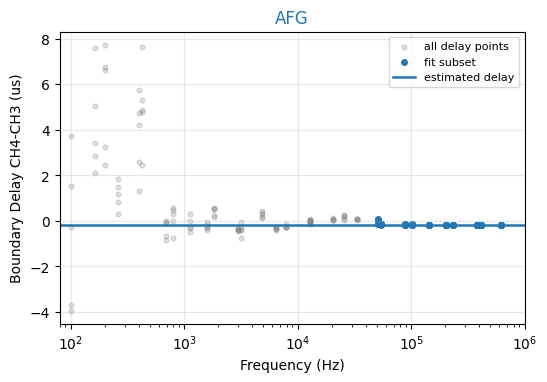

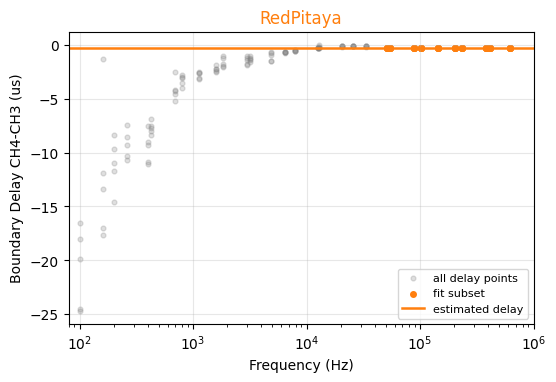

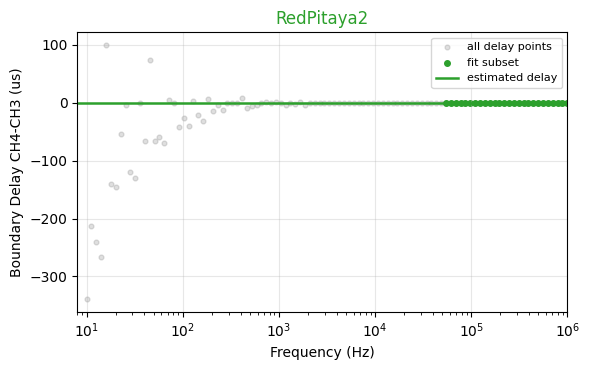

In [4]:
def _weighted_median(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    order = np.argsort(values)
    v = values[order]
    w = weights[order]
    cum = np.cumsum(w)
    cutoff = 0.5 * np.sum(w)
    idx = int(np.searchsorted(cum, cutoff, side="left"))
    return float(v[min(idx, v.size - 1)])


def estimate_constant_boundary_delay(
    points, *, delay_col="boundary_delay_s", min_freq_hz=5e4, weight_power=1.0
):
    work = points[["freq_hz", delay_col]].dropna().copy()
    work = work[
        np.isfinite(work["freq_hz"])
        & np.isfinite(work[delay_col])
        & (work["freq_hz"] > 0)
    ]
    if work.empty:
        return 0.0, work
    hi = work[work["freq_hz"] >= float(min_freq_hz)]
    if len(hi) >= 5:
        work = hi
    freq = work["freq_hz"].to_numpy(dtype=float)
    delay = work[delay_col].to_numpy(dtype=float)
    scale = np.maximum(freq / np.max(freq), 1e-6)
    weights = scale ** float(weight_power)
    est = _weighted_median(delay, weights)
    return float(est), work


# Stage 2: Delay Estimation + Diagnostics
for col, (name, data) in enumerate(dataset_data.items()):
    fig = plt.figure(figsize=(6, 3.8))
    raw = data["raw_points"]
    est_delay_s, delay_samples = estimate_constant_boundary_delay(
        raw,
        min_freq_hz=boundary_delay_min_freq_hz,
        weight_power=boundary_delay_weight_power,
    )
    applied_delay_s = est_delay_s if apply_boundary_delay else 0.0
    data["estimated_delay_s"] = est_delay_s
    data["applied_delay_s"] = applied_delay_s
    data["delay_samples"] = delay_samples

    print(
        f"{name}: estimated delay (CH4-CH3) = {est_delay_s*1e6:+.3f} us, "
        f"applied = {applied_delay_s*1e6:+.3f} us, samples = {len(delay_samples)}"
    )

    plt.scatter(raw["freq_hz"], raw["boundary_delay_s"] * 1e6, s=12, alpha=0.25, color="0.5", label="all delay points")
    plt.scatter(delay_samples["freq_hz"], delay_samples["boundary_delay_s"] * 1e6, s=16, color=data["color"], label="fit subset")
    plt.axhline(est_delay_s * 1e6, color=data["color"], linewidth=1.8, label="estimated delay")
    plt.xscale("log")
    plt.xlim(max(1.0, raw["freq_hz"].min() * 0.8), max_work_hz)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Boundary Delay CH4-CH3 (us)")
    plt.title(name, color=data["color"])
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Stage 3 - Inversion Run
Runs inversion using the configured transfer model and optional time-shift compensation.
Outputs `results` with per-dataset RMS and delay metadata.

In [5]:
# Stage 3: Inversion with Time-Shift Compensation
desired = np.loadtxt("../waveforms/shake_func.csv", delimiter=",")
duration_s = 50e-6
t = np.arange(desired.size) * (duration_s / desired.size)

desired = np.zeros_like(t)
for n in range(1, 10):
    desired += (1 / 11) * np.sin(
        2 * np.pi * np.random.random() * 250e3 * t + np.random.random() * 2 * np.pi
    )
desired *= (1 - np.cos(2 * np.pi * t / duration_s)) / 2

results = {}
for name, data in dataset_data.items():
    transfer = data["transfer"]
    applied_delay_s = data["applied_delay_s"]

    inv = invert_transfer(
        t,
        desired,
        transfer,
        outside_band_mode=outside_band_mode,
        max_work_hz=max_work_hz,
    )
    rms_err = float(np.sqrt(np.mean((inv["predicted_output"] - desired) ** 2)))

    results[name] = {
        **data,
        **inv,
        "rms_error": rms_err,
    }
    print(
        f"{name}: RMS={rms_err:.5f} V, "
        f"delay={data['estimated_delay_s']*1e9:+.1f} ns, "
        f"corr_max={inv['correction_max_hz']:.1f} Hz"
    )

AFG: RMS=0.00000 V, delay=-185.3 ns, corr_max=615848.2 Hz
RedPitaya: RMS=0.00000 V, delay=-287.3 ns, corr_max=615848.2 Hz
RedPitaya2: RMS=0.00000 V, delay=-274.1 ns, corr_max=1000000.0 Hz


## Stage 4A - Calibration Diagnostics
Per-dataset calibration plots (gain and phase) with correction-band markers.

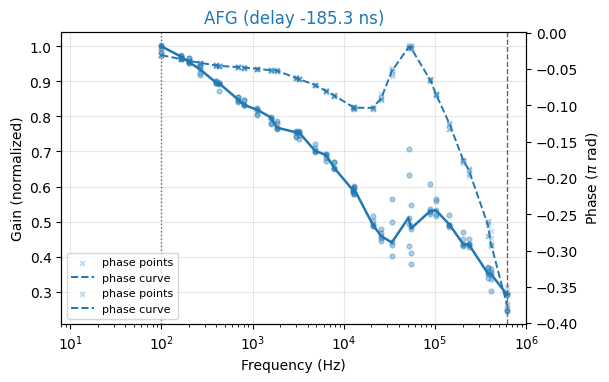

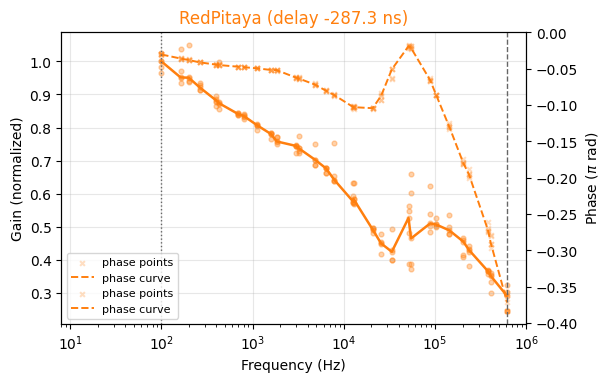

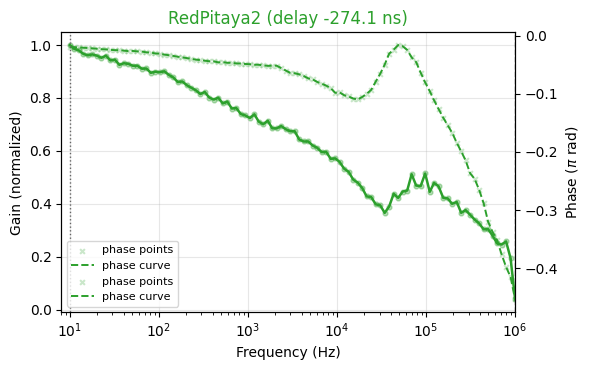

In [6]:
# Stage 4A: Calibration Diagnostics (Separate per Dataset)
global_cal_min = min(res["calibration_min_hz"] for res in results.values())
for col, (name, res) in enumerate(results.items()):
    raw = res["raw_points"]
    transfer = res["transfer"]
    color = res["color"]
    cal_min = res["calibration_min_hz"]
    cal_max = res["calibration_max_hz"]
    corr_max = res["correction_max_hz"]

    line_freq = transfer["freq_hz"]
    line_gain = _interp_log_frequency(line_freq, transfer["freq_hz"].to_numpy(float), transfer["gain"].to_numpy(float))
    line_phase = _interp_log_frequency(line_freq, transfer["freq_hz"].to_numpy(float), transfer["phase_pi"].to_numpy(float))

    fig = plt.figure(figsize=(6, 3.8))
    plt.scatter(raw["freq_hz"], raw["gain"], s=12, alpha=0.35, color=color, label="gain points")
    plt.plot(line_freq, line_gain, color=color, linewidth=1.8, label="gain curve")
    plt.xscale("log")
    plt.xlim(max(1.0, global_cal_min * 0.8), max_work_hz)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Gain (normalized)")
    plt.title(f"{name} (delay {res['estimated_delay_s']*1e9:+.1f} ns)", color=color)
    plt.grid(alpha=0.3)

    axb = plt.twinx()
    axb.scatter(raw["freq_hz"], raw["phase_pi"], s=12, alpha=0.25, color=color, marker="x", label="phase points")
    axb.plot(line_freq, line_phase, color=color, linestyle="--", linewidth=1.4, label="phase curve")
    axb.set_ylabel(r"Phase ($\pi$ rad)")

    plt.axvline(cal_min, color="0.4", linestyle=":", linewidth=1.0)
    plt.axvline(corr_max, color="0.4", linestyle="--", linewidth=1.0)
    if cal_max > corr_max:
        plt.axvline(cal_max, color="0.6", linestyle=":", linewidth=1.0)

    h1, l1 = plt.gca().get_legend_handles_labels()
    h2, l2 = axb.get_legend_handles_labels()
    plt.legend(h1 + h2, l1 + l2, loc="lower left", fontsize=8)

plt.tight_layout()
plt.show()

## Spline-Based Transfer Function Inversion
This section demonstrates a simplified approach:
- Fit splines to gain and phase points
- Use the splines for interpolation
- Invert the transfer function by sampling and inverting the response


In [11]:
from scipy.interpolate import make_interp_spline

def fit_transfer_splines(freq_hz, gain, phase):
    """
    Fit splines to gain and phase data.
    freq_hz: 1D array of frequencies (Hz)
    gain: 1D array of gain values (linear, not dB)
    phase: 1D array of phase values (radians)
    Returns: gain_spline, phase_spline
    """
    gain_spline = make_interp_spline(freq_hz, gain, k=2)
    phase_spline = make_interp_spline(freq_hz, phase, k=2)
    return gain_spline, phase_spline

def invert(ts, desired_output, freq_points, gain_points, phase_points):
    """
    Inversion using spline-fitted transfer function.
    ts: time array (seconds)
    desired_output: desired output waveform (same length as ts)
    freq_points: frequency points (Hz)
    gain_points: gain at freq_points (linear)
    phase_points: phase at freq_points (radians)
    Returns: drive (input signal), predicted_output
    """
    import numpy as np
    n = len(ts)
    dt = float(np.median(np.diff(ts)))
    freq_grid = np.fft.rfftfreq(n, d=dt)
    gain_spline, phase_spline = fit_transfer_splines(freq_points, gain_points, phase_points)
    gain_interp = gain_spline(freq_grid)
    phase_interp = phase_spline(freq_grid)
    H = gain_interp * np.exp(1j * phase_interp)
    eps = 1e-12
    H_inv = np.conj(H) / (np.abs(H)**2 + eps**2)
    drive = np.fft.irfft(np.fft.rfft(desired_output) * H_inv, n=n)
    predicted_output = np.fft.irfft(np.fft.rfft(drive) * H, n=n)
    return drive, predicted_output



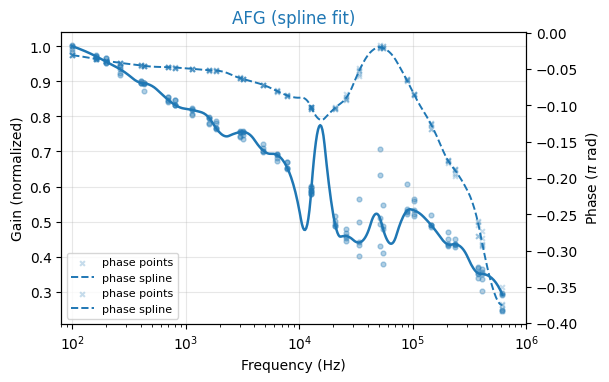

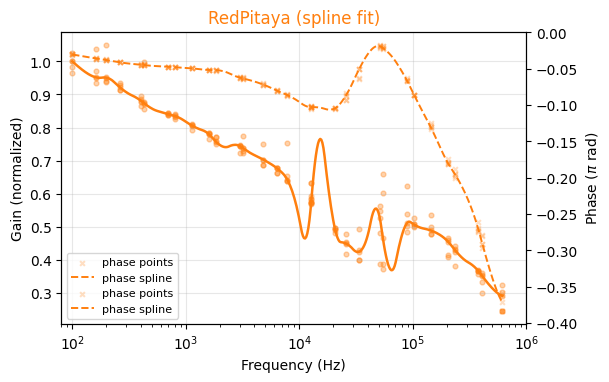

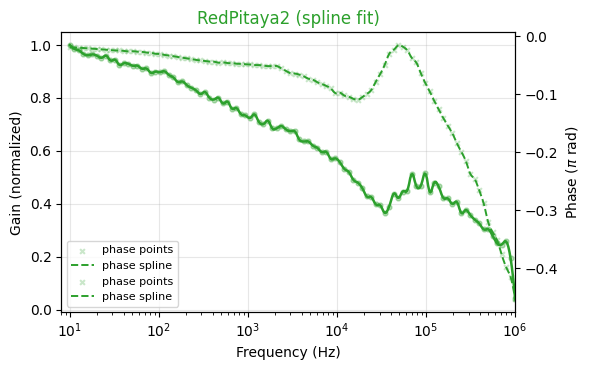

In [12]:
# --- Minimal Spline-Based 4A Calibration Diagnostics ---

# Use the same dataset_data as before, but fit splines and plot using the new process
for col, (name, data) in enumerate(dataset_data.items()):
    raw = data["raw_points"]
    transfer = data["transfer"]
    color = data["color"]
    freq_points = transfer["freq_hz"].to_numpy(float)
    gain_points = transfer["gain"].to_numpy(float)
    phase_points = (np.pi * transfer["phase_pi"].to_numpy(float))  # convert to radians

    # Fit splines
    gain_spline, phase_spline = fit_transfer_splines(freq_points, gain_points, phase_points)
    line_freq = np.logspace(np.log10(freq_points.min()), np.log10(freq_points.max()), 400)
    line_gain = gain_spline(line_freq)
    line_phase = phase_spline(line_freq) / np.pi  # plot as pi units for comparison

    fig = plt.figure(figsize=(6, 3.8))
    plt.scatter(raw["freq_hz"], raw["gain"], s=12, alpha=0.35, color=color, label="gain points")
    plt.plot(line_freq, line_gain, color=color, linewidth=1.8, label="gain spline")
    plt.xscale("log")
    plt.xlim(max(1.0, freq_points.min() * 0.8), max_work_hz)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Gain (normalized)")
    plt.title(f"{name} (spline fit)", color=color)
    plt.grid(alpha=0.3)

    axb = plt.twinx()
    axb.scatter(raw["freq_hz"], raw["phase_pi"], s=12, alpha=0.25, color=color, marker="x", label="phase points")
    axb.plot(line_freq, line_phase, color=color, linestyle="--", linewidth=1.4, label="phase spline")
    axb.set_ylabel(r"Phase ($\pi$ rad)")

    h1, l1 = plt.gca().get_legend_handles_labels()
    h2, l2 = axb.get_legend_handles_labels()
    plt.legend(h1 + h2, l1 + l2, loc="lower left", fontsize=8)

plt.tight_layout()
plt.show()
